# Transformasi Data ETTh1: Dari Mentah hingga Siap Digunakan TimeMixer

Notebook ini mendemonstrasikan tahapan pre-processing data time series ETTh1 dari bentuk mentah hingga siap digunakan oleh model TimeMixer.

## 1. Load dan Explore Data Mentah

In [2]:
import os
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Set path
root_path = 'dataset/ETT-small/'
data_path = 'ETTh1.csv'

# Load data mentah
df_raw = pd.read_csv(os.path.join(root_path, data_path))

print("=" * 80)
print("DATA MENTAH (RAW DATA)")
print("=" * 80)
print(f"\nUkuran dataset: {df_raw.shape}")
print(f"Jumlah baris: {df_raw.shape[0]}, Jumlah kolom: {df_raw.shape[1]}")
print(f"\nNama kolom: {list(df_raw.columns)}")
print(f"\nTipe data:\n{df_raw.dtypes}")
print(f"\nData summary:\n{df_raw.describe()}")
print(f"\nBaris pertama:\n{df_raw.head()}")
print(f"\nCek missing values:\n{df_raw.isnull().sum()}")

DATA MENTAH (RAW DATA)

Ukuran dataset: (17420, 8)
Jumlah baris: 17420, Jumlah kolom: 8

Nama kolom: ['date', 'HUFL', 'HULL', 'MUFL', 'MULL', 'LUFL', 'LULL', 'OT']

Tipe data:
date     object
HUFL    float64
HULL    float64
MUFL    float64
MULL    float64
LUFL    float64
LULL    float64
OT      float64
dtype: object

Data summary:
               HUFL          HULL          MUFL          MULL          LUFL  \
count  17420.000000  17420.000000  17420.000000  17420.000000  17420.000000   
mean       7.375141      2.242242      4.300239      0.881568      3.066062   
std        7.067744      2.042342      6.826978      1.809293      1.164506   
min      -22.705999     -4.756000    -25.087999     -5.934000     -1.188000   
25%        5.827000      0.737000      3.296000     -0.284000      2.315000   
50%        8.774000      2.210000      5.970000      0.959000      2.833000   
75%       11.788000      3.684000      8.635000      2.203000      3.625000   
max       23.643999     10.114000  

## 2. Pembagian Data: Train, Validation, Test

In [3]:
# Parameter dari config SESUAI dengan program TimeMixer Anda
seq_len = 96  # Input sequence length (4 hari)
label_len = 0  # Label length untuk TimeMixer ETTh1 (NO OVERLAP!)
pred_len = 96  # Prediction length (4 hari) - bisa juga 192, 336, 720

# Pembagian data sesuai kode TimeMixer
# Untuk hourly data (ETTh1): 12 * 30 * 24 = 8640 samples (1 tahun)
border1s = [0, 12 * 30 * 24 - seq_len, 12 * 30 * 24 + 4 * 30 * 24 - seq_len]
border2s = [12 * 30 * 24, 12 * 30 * 24 + 4 * 30 * 24, 12 * 30 * 24 + 8 * 30 * 24]

train_border1, train_border2 = border1s[0], border2s[0]
val_border1, val_border2 = border1s[1], border2s[1]
test_border1, test_border2 = border1s[2], border2s[2]

print("=" * 80)
print("PEMBAGIAN DATA (CHRONOLOGICAL SPLIT)")
print("=" * 80)
print(f"\nTotal samples: {len(df_raw)}")
print(f"\nTrain set:      [{train_border1}:{train_border2}] = {train_border2 - train_border1} samples")
print(f"Validation set: [{val_border1}:{val_border2}] = {val_border2 - val_border1} samples")
print(f"Test set:       [{test_border1}:{test_border2}] = {test_border2 - test_border1} samples")

# Extract features (multivariate: semua kolom kecuali 'date')
cols_data = df_raw.columns[1:]  # Exclude 'date' column
features = ['HUFL', 'HULL', 'MUFL', 'MULL', 'LUFL', 'LULL', 'OT']
print(f"\nJumlah features (variabel): {len(features)}")
print(f"Features: {features}")

# Extract data untuk setiap set
train_data = df_raw[cols_data].iloc[train_border1:train_border2]
val_data = df_raw[cols_data].iloc[val_border1:val_border2]
test_data = df_raw[cols_data].iloc[test_border1:test_border2]

print(f"\nTrain data shape: {train_data.shape}")
print(f"Validation data shape: {val_data.shape}")
print(f"Test data shape: {test_data.shape}")

print(f"\n⚠️ PERHATIAN: label_len = {label_len} (Output HANYA prediksi, TANPA overlap!)")

PEMBAGIAN DATA (CHRONOLOGICAL SPLIT)

Total samples: 17420

Train set:      [0:8640] = 8640 samples
Validation set: [8544:11520] = 2976 samples
Test set:       [11424:14400] = 2976 samples

Jumlah features (variabel): 7
Features: ['HUFL', 'HULL', 'MUFL', 'MULL', 'LUFL', 'LULL', 'OT']

Train data shape: (8640, 7)
Validation data shape: (2976, 7)
Test data shape: (2976, 7)

⚠️ PERHATIAN: label_len = 0 (Output HANYA prediksi, TANPA overlap!)


## 3. Normalisasi Data (Standardization)

In [4]:
# StandardScaler fit hanya pada training data
scaler = StandardScaler()
scaler.fit(train_data.values)

# Transform semua data menggunakan parameter dari training
train_data_scaled = scaler.transform(train_data.values)
val_data_scaled = scaler.transform(val_data.values)
test_data_scaled = scaler.transform(test_data.values)

print("=" * 80)
print("NORMALISASI DATA (STANDARDIZATION)")
print("=" * 80)
print("\nMetode: StandardScaler (Z-score normalization)")
print(f"Formula: x_normalized = (x - mean) / std")

print(f"\nMean dari setiap feature (dari training data):")
for i, feat in enumerate(features):
    print(f"  {feat:6s}: {scaler.mean_[i]:8.4f}")

print(f"\nStandard deviation dari setiap feature:")
for i, feat in enumerate(features):
    print(f"  {feat:6s}: {scaler.scale_[i]:8.4f}")

print(f"\n\nData SEBELUM Normalisasi (contoh 3 baris pertama train data):")
print(train_data.head(3))

print(f"\nData SESUDAH Normalisasi (contoh 3 baris pertama train data):")
print(pd.DataFrame(train_data_scaled[:3], columns=features))

# Verifikasi: data normalized memiliki mean ≈ 0 dan std ≈ 1
print(f"\nVerifikasi normalisasi:")
print(f"Mean dari train_data_scaled: {train_data_scaled.mean(axis=0)}")
print(f"Std dari train_data_scaled: {train_data_scaled.std(axis=0)}")

NORMALISASI DATA (STANDARDIZATION)

Metode: StandardScaler (Z-score normalization)
Formula: x_normalized = (x - mean) / std

Mean dari setiap feature (dari training data):
  HUFL  :   7.9377
  HULL  :   2.0210
  MUFL  :   5.0798
  MULL  :   0.7462
  LUFL  :   2.7818
  LULL  :   0.7885
  OT    :  17.1283

Standard deviation dari setiap feature:
  HUFL  :   5.8127
  HULL  :   2.0901
  MUFL  :   5.5188
  MULL  :   1.9264
  LUFL  :   1.0235
  LULL  :   0.6302
  OT    :   9.1765


Data SEBELUM Normalisasi (contoh 3 baris pertama train data):
    HUFL   HULL   MUFL   MULL   LUFL   LULL         OT
0  5.827  2.009  1.599  0.462  4.203  1.340  30.531000
1  5.693  2.076  1.492  0.426  4.142  1.371  27.787001
2  5.157  1.741  1.279  0.355  3.777  1.218  27.787001

Data SESUDAH Normalisasi (contoh 3 baris pertama train data):
       HUFL      HULL      MUFL      MULL      LUFL      LULL        OT
0 -0.363123 -0.005760 -0.630712 -0.147523  1.388575  0.875143  1.460552
1 -0.386176  0.026296 -0.65010

## 4. Ekstrak Time Features (Temporal Information)

In [5]:
# Extract time features untuk setiap split
df_stamp_train = df_raw[['date']].iloc[train_border1:train_border2].reset_index(drop=True)
df_stamp_val = df_raw[['date']].iloc[val_border1:val_border2].reset_index(drop=True)
df_stamp_test = df_raw[['date']].iloc[test_border1:test_border2].reset_index(drop=True)

# Convert date to datetime
df_stamp_train['date'] = pd.to_datetime(df_stamp_train['date'])
df_stamp_val['date'] = pd.to_datetime(df_stamp_val['date'])
df_stamp_test['date'] = pd.to_datetime(df_stamp_test['date'])

# Extract temporal features
df_stamp_train['month'] = df_stamp_train['date'].apply(lambda row: row.month)
df_stamp_train['day'] = df_stamp_train['date'].apply(lambda row: row.day)
df_stamp_train['weekday'] = df_stamp_train['date'].apply(lambda row: row.weekday())
df_stamp_train['hour'] = df_stamp_train['date'].apply(lambda row: row.hour)

df_stamp_val['month'] = df_stamp_val['date'].apply(lambda row: row.month)
df_stamp_val['day'] = df_stamp_val['date'].apply(lambda row: row.day)
df_stamp_val['weekday'] = df_stamp_val['date'].apply(lambda row: row.weekday())
df_stamp_val['hour'] = df_stamp_val['date'].apply(lambda row: row.hour)

df_stamp_test['month'] = df_stamp_test['date'].apply(lambda row: row.month)
df_stamp_test['day'] = df_stamp_test['date'].apply(lambda row: row.day)
df_stamp_test['weekday'] = df_stamp_test['date'].apply(lambda row: row.weekday())
df_stamp_test['hour'] = df_stamp_test['date'].apply(lambda row: row.hour)

# Drop date column dan convert to numpy
time_features_train = df_stamp_train.drop(['date'], axis=1).values
time_features_val = df_stamp_val.drop(['date'], axis=1).values
time_features_test = df_stamp_test.drop(['date'], axis=1).values

print("=" * 80)
print("TEMPORAL FEATURES (TIME INFORMATION)")
print("=" * 80)
print("\nTemporal features yang di-extract:")
print("  - month: bulan dalam tahun (1-12)")
print("  - day: hari dalam bulan (1-31)")
print("  - weekday: hari dalam minggu (0-6, 0=Monday)")
print("  - hour: jam dalam hari (0-23)")

print(f"\nTime features shape:")
print(f"  Train: {time_features_train.shape}")
print(f"  Validation: {time_features_val.shape}")
print(f"  Test: {time_features_test.shape}")

print(f"\nContoh 5 baris pertama time features:")
print(pd.DataFrame(time_features_train[:5], columns=['month', 'day', 'weekday', 'hour']))

TEMPORAL FEATURES (TIME INFORMATION)

Temporal features yang di-extract:
  - month: bulan dalam tahun (1-12)
  - day: hari dalam bulan (1-31)
  - weekday: hari dalam minggu (0-6, 0=Monday)
  - hour: jam dalam hari (0-23)

Time features shape:
  Train: (8640, 4)
  Validation: (2976, 4)
  Test: (2976, 4)

Contoh 5 baris pertama time features:
   month  day  weekday  hour
0      7    1        4     0
1      7    1        4     1
2      7    1        4     2
3      7    1        4     3
4      7    1        4     4


## 5. Buat Sequences untuk Time Series (Sliding Window)

In [6]:
def create_sequences(data, time_features, seq_len, label_len, pred_len):
    """
    Membuat sequences menggunakan sliding window untuk time series forecasting
    
    Parameters:
    - data: normalized time series data (T, C) dimana T=timesteps, C=channels
    - time_features: temporal features (T, F) dimana F=temporal features
    - seq_len: panjang input sequence
    - label_len: panjang label (overlap antara encoder dan decoder)
             CATATAN: Untuk TimeMixer ETTh1, label_len=0 (TANPA OVERLAP)
    - pred_len: panjang prediction (output)
    
    Returns:
    - sequences: list of (input_seq, target_seq, input_time, target_time)
    """
    sequences = []
    
    num_samples = len(data) - seq_len - pred_len + 1
    
    for i in range(num_samples):
        # Input sequence: dari index i hingga i + seq_len
        s_begin = i
        s_end = s_begin + seq_len
        
        # Output sequence: 
        # Jika label_len = 0: hanya prediksi (tanpa overlap)
        # Jika label_len > 0: overlap + prediksi
        if label_len == 0:
            # Untuk TimeMixer: output dimulai dari s_end
            r_begin = s_end
            r_end = r_begin + pred_len
        else:
            # Untuk model lain dengan label_len > 0
            r_begin = s_end - label_len
            r_end = r_begin + label_len + pred_len
        
        seq_x = data[s_begin:s_end]
        seq_y = data[r_begin:r_end]
        
        seq_x_mark = time_features[s_begin:s_end]
        seq_y_mark = time_features[r_begin:r_end]
        
        sequences.append((seq_x, seq_y, seq_x_mark, seq_y_mark))
    
    return sequences

# Create sequences untuk setiap split
train_sequences = create_sequences(train_data_scaled, time_features_train, seq_len, label_len, pred_len)
val_sequences = create_sequences(val_data_scaled, time_features_val, seq_len, label_len, pred_len)
test_sequences = create_sequences(test_data_scaled, time_features_test, seq_len, label_len, pred_len)

print("=" * 80)
print("MEMBUAT SEQUENCES (SLIDING WINDOW) - SESUAI PROGRAM TIMEMIXER")
print("=" * 80)
print(f"\nParameter:")
print(f"  seq_len (input length):     {seq_len} timesteps (4 hari)")
print(f"  label_len (overlap):        {label_len} timesteps (TANPA OVERLAP untuk TimeMixer!)")
print(f"  pred_len (prediction length): {pred_len} timesteps (4 hari)")

print(f"\nTotal sequences yang dibuat:")
print(f"  Train: {len(train_sequences)} sequences")
print(f"  Validation: {len(val_sequences)} sequences")
print(f"  Test: {len(test_sequences)} sequences")

# Tampilkan contoh satu sequence
idx = 0
seq_x, seq_y, seq_x_mark, seq_y_mark = train_sequences[idx]

print(f"\n\nCONTOH 1 SEQUENCE (index {idx}):")
print(f"\nInput sequence shape: {seq_x.shape} → (96 timesteps, 7 features)")
print(f"Input data (3 timesteps pertama):")
print(pd.DataFrame(seq_x[:3], columns=features))

if label_len == 0:
    print(f"\nOutput sequence shape: {seq_y.shape} → ({pred_len} timesteps MURNI prediksi)")
else:
    print(f"\nOutput sequence shape: {seq_y.shape} → ({label_len} + {pred_len} = {label_len + pred_len} timesteps)")

print(f"Output data (3 timesteps pertama):")
print(pd.DataFrame(seq_y[:3], columns=features))

print(f"\nInput time features shape: {seq_x_mark.shape}")
print(f"Input time features (3 timesteps pertama):")
print(pd.DataFrame(seq_x_mark[:3], columns=['month', 'day', 'weekday', 'hour']))

print(f"\nOutput time features shape: {seq_y_mark.shape}")

MEMBUAT SEQUENCES (SLIDING WINDOW) - SESUAI PROGRAM TIMEMIXER

Parameter:
  seq_len (input length):     96 timesteps (4 hari)
  label_len (overlap):        0 timesteps (TANPA OVERLAP untuk TimeMixer!)
  pred_len (prediction length): 96 timesteps (4 hari)

Total sequences yang dibuat:
  Train: 8449 sequences
  Validation: 2785 sequences
  Test: 2785 sequences


CONTOH 1 SEQUENCE (index 0):

Input sequence shape: (96, 7) → (96 timesteps, 7 features)
Input data (3 timesteps pertama):
       HUFL      HULL      MUFL      MULL      LUFL      LULL        OT
0 -0.363123 -0.005760 -0.630712 -0.147523  1.388575  0.875143  1.460552
1 -0.386176  0.026296 -0.650101 -0.166211  1.328977  0.924330  1.161527
2 -0.478387 -0.133983 -0.688696 -0.203068  0.972365  0.681565  1.161527

Output sequence shape: (96, 7) → (96 timesteps MURNI prediksi)
Output data (3 timesteps pertama):
       HUFL      HULL      MUFL      MULL      LUFL      LULL        OT
0  0.696961  1.724775  0.669934  1.143500  0.406672  1.

## 6. Multi-Scale Processing (Down-sampling)

In [7]:
# Ambil satu sequence untuk demonstrasi multi-scale processing
seq_x_sample, seq_y_sample, seq_x_mark_sample, seq_y_mark_sample = train_sequences[0]

# Convert to torch tensor
x_enc = torch.FloatTensor(seq_x_sample).unsqueeze(0)  # Add batch dimension: (1, 96, 7)
x_mark_enc = torch.FloatTensor(seq_x_mark_sample).unsqueeze(0)  # (1, 96, 4)

print("=" * 80)
print("MULTI-SCALE PROCESSING (DOWN-SAMPLING) - SESUAI PROGRAM TIMEMIXER")
print("=" * 80)

# Parameter TimeMixer DARI PROGRAM ANDA
down_sampling_window = 2
down_sampling_layers = 3  # UBAH dari 2 menjadi 3 (sesuai program)
down_sampling_method = 'avg'  # atau 'max', 'conv'

print(f"\nParameter (dari TimeMixer_ETTh1.sh):")
print(f"  down_sampling_window: {down_sampling_window}")
print(f"  down_sampling_layers: {down_sampling_layers}")
print(f"  down_sampling_method: {down_sampling_method}")

# Simulate multi-scale processing
# B,T,C -> B,C,T untuk pooling
x_enc_bct = x_enc.permute(0, 2, 1)  # (1, 7, 96)

print(f"\nInput shape (original): {x_enc.shape} → (batch=1, time=96, channels=7)")
print(f"Input shape (for pooling): {x_enc_bct.shape} → (batch=1, channels=7, time=96)")

if down_sampling_method == 'avg':
    down_pool = torch.nn.AvgPool1d(down_sampling_window)

x_enc_list = [x_enc_bct.permute(0, 2, 1)]  # Scale 0: original
x_mark_list = [x_mark_enc]

x_enc_ori = x_enc_bct
x_mark_enc_ori = x_mark_enc

for layer in range(down_sampling_layers):
    x_enc_down = down_pool(x_enc_ori)
    x_enc_list.append(x_enc_down.permute(0, 2, 1))
    
    x_mark_down = x_mark_enc_ori[:, ::down_sampling_window, :]
    x_mark_list.append(x_mark_down)
    
    x_enc_ori = x_enc_down
    x_mark_enc_ori = x_mark_down

print(f"\nMulti-scale representations ({down_sampling_layers + 1} total scales):")
for i, x_scale in enumerate(x_enc_list):
    print(f"  Scale {i}: {x_scale.shape} → (batch=1, time={x_scale.shape[1]}, channels=7)")

print(f"\nVisualisasi:")
print(f"  Scale 0 (original): 96 timesteps   → |████████████████████|")
print(f"  Scale 1 (down 2x):   48 timesteps  → |██████████|")
print(f"  Scale 2 (down 4x):   24 timesteps  → |█████|")
print(f"  Scale 3 (down 8x):   12 timesteps  → |██|")
print(f"\nDari 96 timesteps:")
print(f"  - Setelah 1x down-sampling (÷2): 96/2 = 48 timesteps")
print(f"  - Setelah 2x down-sampling (÷4): 96/4 = 24 timesteps")
print(f"  - Setelah 3x down-sampling (÷8): 96/8 = 12 timesteps")

MULTI-SCALE PROCESSING (DOWN-SAMPLING) - SESUAI PROGRAM TIMEMIXER

Parameter (dari TimeMixer_ETTh1.sh):
  down_sampling_window: 2
  down_sampling_layers: 3
  down_sampling_method: avg

Input shape (original): torch.Size([1, 96, 7]) → (batch=1, time=96, channels=7)
Input shape (for pooling): torch.Size([1, 7, 96]) → (batch=1, channels=7, time=96)

Multi-scale representations (4 total scales):
  Scale 0: torch.Size([1, 96, 7]) → (batch=1, time=96, channels=7)
  Scale 1: torch.Size([1, 48, 7]) → (batch=1, time=48, channels=7)
  Scale 2: torch.Size([1, 24, 7]) → (batch=1, time=24, channels=7)
  Scale 3: torch.Size([1, 12, 7]) → (batch=1, time=12, channels=7)

Visualisasi:
  Scale 0 (original): 96 timesteps   → |████████████████████|
  Scale 1 (down 2x):   48 timesteps  → |██████████|
  Scale 2 (down 4x):   24 timesteps  → |█████|
  Scale 3 (down 8x):   12 timesteps  → |██|

Dari 96 timesteps:
  - Setelah 1x down-sampling (÷2): 96/2 = 48 timesteps
  - Setelah 2x down-sampling (÷4): 96/4 = 2

## 7. Data Matang Akhir (Final Prepared Data)

In [8]:
print("=" * 80)
print("RINGKASAN: DATA MATANG SIAP UNTUK MODEL TIMEMIXER (SESUAI PROGRAM ANDA)")
print("=" * 80)

print("\n📊 STRUKTUR DATA SETELAH PRE-PROCESSING:\n")

print("1️⃣  TRAINING SET")
print("   ├─ Sequences: {} samples".format(len(train_sequences)))
print("   ├─ Input (x_enc): (batch_size, 96, 7)")
print("   │  └─ 96 timesteps × 7 features [HUFL, HULL, MUFL, MULL, LUFL, LULL, OT]")
print("   ├─ Output (x_dec): (batch_size, {}, 7)".format(pred_len))
print("   │  └─ {} timesteps MURNI PREDIKSI (label_len=0, TANPA OVERLAP!)".format(pred_len))
print("   ├─ Input Time Marks: (batch_size, 96, 4)")
print("   │  └─ [month, day, weekday, hour]")
print("   └─ Output Time Marks: (batch_size, {}, 4)".format(pred_len))

print("\n2️⃣  VALIDATION SET")
print("   ├─ Sequences: {} samples".format(len(val_sequences)))
print("   └─ Same structure as training set")

print("\n3️⃣  TEST SET")
print("   ├─ Sequences: {} samples".format(len(test_sequences)))
print("   └─ Same structure as training set")

print("\n\n📈 TRANSFORMASI DATA STEP-BY-STEP (SESUAI PROGRAM):\n")

print("MENTAH (RAW):")
print(f"  Shape: ({len(df_raw)}, 8)")
print(f"  Columns: date, HUFL, HULL, MUFL, MULL, LUFL, LULL, OT")
print(f"  Values: e.g., date='2016-07-01', HUFL=5.827, OT=30.531")

print("\n↓ DROP 'date' & SELECT COLUMNS (features='M')")

print("\n  Shape: ({}, 7)".format(len(df_raw)))
print(f"  Columns: HUFL, HULL, MUFL, MULL, LUFL, LULL, OT")

print("\n↓ SPLIT (Train/Val/Test dengan Chronological Order)")

print(f"\n  Train: [0:{train_border2}]      = {train_border2} samples")
print(f"  Val:   [{val_border1}:{val_border2}] = {val_border2-val_border1} samples")
print(f"  Test:  [{test_border1}:{test_border2}] = {test_border2-test_border1} samples")

print("\n↓ NORMALIZE (StandardScaler - fit on train_data)")

print("\n  Formula: x_norm = (x - mean) / std")
print(f"  Shape: sama (train={train_border2}, val={val_border2-val_border1}, test={test_border2-test_border1}, features=7)")
print(f"  Range: nilai normalisasi ≈ [-2, 2] atau [-3, 3] tergantung distribusi")

print("\n↓ CREATE SEQUENCES (Sliding Window) ⚠️ label_len=0!")

print(f"\n  Shape: (num_sequences, seq_len or pred_len, features)")
print(f"  Train sequences: {len(train_sequences)}")
print(f"  Val sequences: {len(val_sequences)}")
print(f"  Test sequences: {len(test_sequences)}")
print(f"  Input: 96 timesteps | Output: {pred_len} timesteps (HANYA prediksi)")

print("\n↓ MULTI-SCALE PROCESSING (TimeMixer - 4 Scales!) 🔄")

print(f"\n  Original (Scale 0): seq_len=96")
print(f"  Scale 1 (÷2):       seq_len=48")
print(f"  Scale 2 (÷4):       seq_len=24")
print(f"  Scale 3 (÷8):       seq_len=12  ← TAMBAHAN dari program!")
print(f"  Total scales: {down_sampling_layers + 1}")

print("\n↓ EMBEDDING & NORMALIZATION (Channel-wise)")

print(f"\n  Per-channel normalization untuk setiap scale")
print(f"  TokenEmbedding + TemporalEmbedding")
print(f"  d_model = 16 (dari program Anda)")
print(f"  Output: (batch_size, seq_len, d_model=16)")

print("\n\n" + "=" * 80)
print("✅ SIAP UNTUK FORWARD PASS KE MODEL TIMEMIXER")
print("=" * 80)
print("\n⚠️ PERBEDAAN UTAMA DARI DEMO AWAL:")
print("   1. label_len = 0 (TANPA overlap encoder-decoder)")
print("   2. Output shape: ({}, 7) bukan (144, 7)".format(pred_len))
print("   3. Down-sampling layers = 3 (4 scales total)")
print("   4. down_sampling_window = 2")
print("   5. down_sampling_method = 'avg'")

RINGKASAN: DATA MATANG SIAP UNTUK MODEL TIMEMIXER (SESUAI PROGRAM ANDA)

📊 STRUKTUR DATA SETELAH PRE-PROCESSING:

1️⃣  TRAINING SET
   ├─ Sequences: 8449 samples
   ├─ Input (x_enc): (batch_size, 96, 7)
   │  └─ 96 timesteps × 7 features [HUFL, HULL, MUFL, MULL, LUFL, LULL, OT]
   ├─ Output (x_dec): (batch_size, 96, 7)
   │  └─ 96 timesteps MURNI PREDIKSI (label_len=0, TANPA OVERLAP!)
   ├─ Input Time Marks: (batch_size, 96, 4)
   │  └─ [month, day, weekday, hour]
   └─ Output Time Marks: (batch_size, 96, 4)

2️⃣  VALIDATION SET
   ├─ Sequences: 2785 samples
   └─ Same structure as training set

3️⃣  TEST SET
   ├─ Sequences: 2785 samples
   └─ Same structure as training set


📈 TRANSFORMASI DATA STEP-BY-STEP (SESUAI PROGRAM):

MENTAH (RAW):
  Shape: (17420, 8)
  Columns: date, HUFL, HULL, MUFL, MULL, LUFL, LULL, OT
  Values: e.g., date='2016-07-01', HUFL=5.827, OT=30.531

↓ DROP 'date' & SELECT COLUMNS (features='M')

  Shape: (17420, 7)
  Columns: HUFL, HULL, MUFL, MULL, LUFL, LULL, 

## 8. Visualisasi Perbandingan Data Mentah vs Data Matang

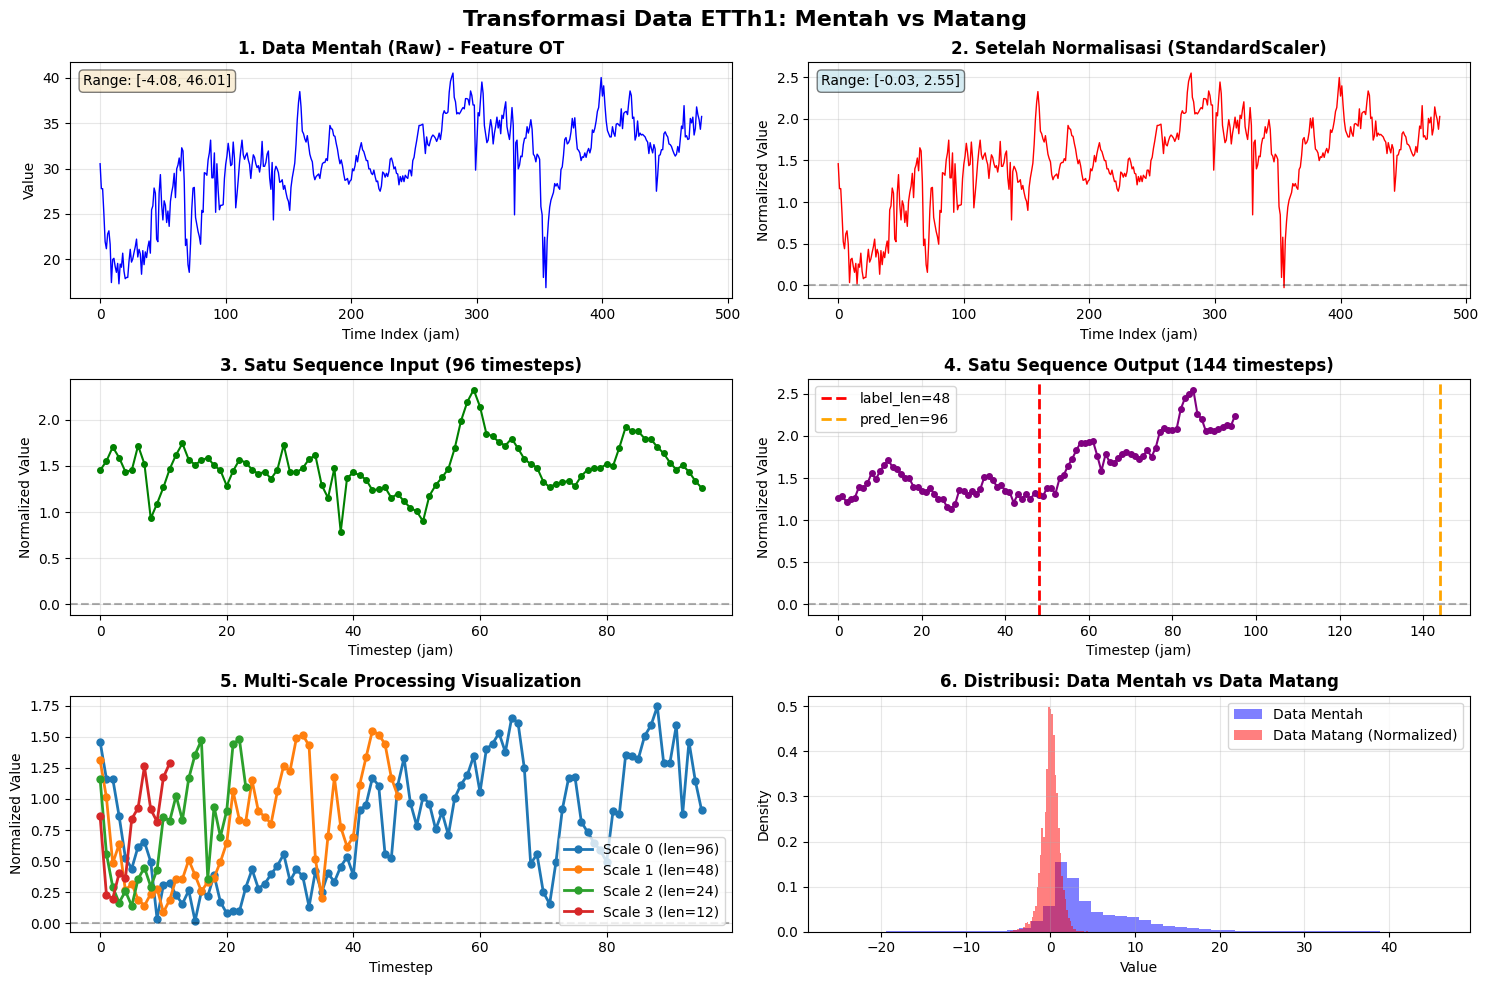

✓ Visualisasi selesai!


In [9]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 2, figsize=(15, 10))
fig.suptitle('Transformasi Data ETTh1: Mentah vs Matang', fontsize=16, fontweight='bold')

# Plot 1: Data Mentah - Feature OT
ax = axes[0, 0]
ax.plot(df_raw['OT'].head(480), linewidth=1, color='blue')
ax.set_title('1. Data Mentah (Raw) - Feature OT', fontweight='bold')
ax.set_ylabel('Value')
ax.set_xlabel('Time Index (jam)')
ax.grid(True, alpha=0.3)
ax.text(0.02, 0.95, f'Range: [{df_raw["OT"].min():.2f}, {df_raw["OT"].max():.2f}]',
        transform=ax.transAxes, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Plot 2: Data Normalisasi - Feature OT
ax = axes[0, 1]
ax.plot(train_data_scaled[:480, -1], linewidth=1, color='red')
ax.set_title('2. Setelah Normalisasi (StandardScaler)', fontweight='bold')
ax.set_ylabel('Normalized Value')
ax.set_xlabel('Time Index (jam)')
ax.grid(True, alpha=0.3)
ax.axhline(y=0, color='k', linestyle='--', alpha=0.3)
ax.text(0.02, 0.95, f'Range: [{train_data_scaled[:480, -1].min():.2f}, {train_data_scaled[:480, -1].max():.2f}]',
        transform=ax.transAxes, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))

# Plot 3: Satu Sequence Input (96 timesteps)
ax = axes[1, 0]
seq_x_demo, _, _, _ = train_sequences[100]
ax.plot(seq_x_demo[:, -1], 'o-', linewidth=1.5, markersize=4, color='green')
ax.set_title('3. Satu Sequence Input (96 timesteps)', fontweight='bold')
ax.set_ylabel('Normalized Value')
ax.set_xlabel('Timestep (jam)')
ax.grid(True, alpha=0.3)
ax.axhline(y=0, color='k', linestyle='--', alpha=0.3)

# Plot 4: Satu Sequence Output (144 timesteps)
ax = axes[1, 1]
_, seq_y_demo, _, _ = train_sequences[100]
ax.plot(seq_y_demo[:, -1], 'o-', linewidth=1.5, markersize=4, color='purple')
ax.axvline(x=48, color='red', linestyle='--', linewidth=2, label='label_len=48')
ax.axvline(x=144, color='orange', linestyle='--', linewidth=2, label='pred_len=96')
ax.set_title('4. Satu Sequence Output (144 timesteps)', fontweight='bold')
ax.set_ylabel('Normalized Value')
ax.set_xlabel('Timestep (jam)')
ax.grid(True, alpha=0.3)
ax.axhline(y=0, color='k', linestyle='--', alpha=0.3)
ax.legend()

# Plot 5: Multi-scale Representations
ax = axes[2, 0]
for i, x_scale in enumerate(x_enc_list):
    x_scale_np = x_scale.squeeze(0)[:, -1].numpy()
    ax.plot(x_scale_np, 'o-', label=f'Scale {i} (len={len(x_scale_np)})', linewidth=2, markersize=5)
ax.set_title('5. Multi-Scale Processing Visualization', fontweight='bold')
ax.set_ylabel('Normalized Value')
ax.set_xlabel('Timestep')
ax.grid(True, alpha=0.3)
ax.axhline(y=0, color='k', linestyle='--', alpha=0.3)
ax.legend()

# Plot 6: Distribution perbandingan
ax = axes[2, 1]
data_mentah = df_raw[['HUFL', 'HULL', 'MUFL', 'MULL', 'LUFL', 'LULL', 'OT']].values.flatten()
data_matang = train_data_scaled.flatten()

ax.hist(data_mentah, bins=50, alpha=0.5, label='Data Mentah', color='blue', density=True)
ax.hist(data_matang, bins=50, alpha=0.5, label='Data Matang (Normalized)', color='red', density=True)
ax.set_title('6. Distribusi: Data Mentah vs Data Matang', fontweight='bold')
ax.set_ylabel('Density')
ax.set_xlabel('Value')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("✓ Visualisasi selesai!")

## 9. Tabel Perbandingan: Data Mentah vs Data Matang

In [10]:
comparison_data = {
    'Aspek': [
        'Format File',
        'Dimensi',
        'Columns',
        'Range Nilai',
        'Struktur Waktu',
        'Processing',
        'Output Format',
        'Batch Size',
        'Ready for Model'
    ],
    'Data Mentah': [
        'CSV File',
        f'({len(df_raw)}, 8)',
        'date, HUFL, HULL, MUFL, MULL, LUFL, LULL, OT',
        f'Berbeda per feature (e.g., OT: [{df_raw["OT"].min():.2f}, {df_raw["OT"].max():.2f}])',
        'Setiap baris = 1 jam',
        'Belum ada',
        'DataFrame 2D',
        '-',
        '❌ Tidak'
    ],
    'Data Matang (PROGRAM ANDA)': [
        'NumPy Array / Tensor',
        f'Sequences: {len(train_sequences)}',
        '7 features: [HUFL, HULL, MUFL, MULL, LUFL, LULL, OT]',
        f'Normalized: [{train_data_scaled.min():.2f}, {train_data_scaled.max():.2f}]',
        'Sequences + Time Features (month, day, weekday, hour)',
        'Standardized + Multi-scale (4 scales)',
        'Tuple: (input_seq[96,7], output_seq[{},7], input_time, output_time)'.format(pred_len),
        '128 (dari script)',
        '✅ Ya'
    ]
}

df_comparison = pd.DataFrame(comparison_data)

print("=" * 140)
print("TABEL PERBANDINGAN: DATA MENTAH vs DATA MATANG (SESUAI PROGRAM TIMEMIXER ANDA)")
print("=" * 140)
print()
print(df_comparison.to_string(index=False))
print()
print("=" * 140)

# Tabel detail untuk satu sample sequence
print("\n\nDETAIL UNTUK SATU SAMPLE SEQUENCE (SESUAI PROGRAM):")
print("=" * 140)

seq_x_sample, seq_y_sample, seq_x_mark_sample, seq_y_mark_sample = train_sequences[0]

detail_data = {
    'Komponen': [
        'Input Data (x_enc)',
        'Output Data (x_dec)',
        'Input Time Features',
        'Output Time Features',
        'Input Data Shape',
        'Output Data Shape',
        'Temporal Embedding Dim',
        'Ready for Embedding?',
        'label_len'
    ],
    'Deskripsi': [
        f'Normalized time series untuk encoder',
        f'Normalized time series untuk decoder (HANYA prediksi)',
        f'Temporal features untuk input (jam, hari, minggu, bulan)',
        f'Temporal features untuk output',
        f'{seq_x_sample.shape} → (96 timesteps, 7 features)',
        f'{seq_y_sample.shape} → ({pred_len} timesteps MURNI, 7 features)',
        f'4 features (month, day, weekday, hour)',
        f'Ya, siap untuk embedding layer',
        f'{label_len} (TANPA OVERLAP!)'
    ],
    'Contoh Nilai / Catatan': [
        f'Normalized, range ≈ [{seq_x_sample.min():.2f}, {seq_x_sample.max():.2f}]',
        f'Normalized, range ≈ [{seq_y_sample.min():.2f}, {seq_y_sample.max():.2f}]',
        f'{seq_x_mark_sample[:2]}',
        f'{seq_y_mark_sample[:2]}',
        f'numpy array',
        f'numpy array (bukan 144 seperti demo!)',
        f'integer values',
        f'✅ Yes',
        f'Perbedaan utama dari demo'
    ]
}

df_detail = pd.DataFrame(detail_data)
print(df_detail.to_string(index=False))
print("\n" + "=" * 140)

# Tabel parameter TimeMixer
print("\n\nPARAMETER TIMEMIXER (DARI run.py dan SCRIPT Anda):")
print("=" * 140)

timemixer_params = {
    'Parameter': [
        'task_name',
        'model',
        'data',
        'features',
        'seq_len',
        'label_len',
        'pred_len',
        'enc_in',
        'c_out',
        'd_model',
        'd_ff',
        'e_layers',
        'd_layers',
        'down_sampling_layers',
        'down_sampling_window',
        'down_sampling_method',
        'batch_size',
        'learning_rate',
        'train_epochs'
    ],
    'Value (Program Anda)': [
        'long_term_forecast',
        'TimeMixer',
        'ETTh1',
        'M (multivariate)',
        '96',
        '0 ⚠️',
        '96 (or 192, 336, 720)',
        '7',
        '7',
        '16',
        '32',
        '2',
        '1',
        '3 ⚠️',
        '2',
        'avg',
        '128',
        '0.01',
        '10'
    ]
}

df_params = pd.DataFrame(timemixer_params)
print(df_params.to_string(index=False))
print("\n" + "=" * 140)

TABEL PERBANDINGAN: DATA MENTAH vs DATA MATANG (SESUAI PROGRAM TIMEMIXER ANDA)

          Aspek                                    Data Mentah                                          Data Matang (PROGRAM ANDA)
    Format File                                       CSV File                                                NumPy Array / Tensor
        Dimensi                                     (17420, 8)                                                     Sequences: 8449
        Columns   date, HUFL, HULL, MUFL, MULL, LUFL, LULL, OT                7 features: [HUFL, HULL, MUFL, MULL, LUFL, LULL, OT]
    Range Nilai Berbeda per feature (e.g., OT: [-4.08, 46.01])                                           Normalized: [-4.78, 4.99]
 Struktur Waktu                           Setiap baris = 1 jam               Sequences + Time Features (month, day, weekday, hour)
     Processing                                      Belum ada                               Standardized + Multi-scale (4 scales)
  O